In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Section 1: Understanding Data and Data Cleaning

In [2]:
# import data from data/raw.csv
data = pd.read_csv("data/raw.csv")
data.head()

,ID,Country,PA_Days,VA_Weekly_Days,VA_Daily_Hours,MIA_Weekly_Days,MIA_Daily_Hours,Sedentary_Daily_Hours,Hours_Slept,Uni_Facilities,...,Relaxedness,Coping,Closeness,University,Year,Gender,BMI,GPA,Campus,Sports_Club
0,1577,Singapore,1,2,4.00,4,4.00,4.00,9.00,2,...,2,3,3,NTU Singapore - National Institute of Education,2,1,27.755102,3.5,1,2
1,1381,Singapore,2,0,0.00,0,0.00,12.00,5.00,2,...,1,4,2,NTU Singapore - National Institute of Education,3,2,24.023809,4.5,1,2
2,1413,Singapore,2,1,2.75,1,3.00,15.25,9.50,1,...,5,4,2,NTU Singapore - National Institute of Education,1,1,NaN,NaN,2,2
3,1560,Singapore,3,0,4.75,0,0.00,5.00,9.00,1,...,4,4,4,NTU Singapore - National Institute of Education,3,1,22.408179,4.5,1,2
4,1475,Singapore,6,5,2.50,4,1.75,13.25,3.25,1,...,4,3,3,NTU Singapore - National Institute of Education,3,2,NaN,NaN,2,1


In [3]:
# preprocess data and save as data/processed.csv

from src.preprocessing import preprocess

data = preprocess(data)
data.to_csv("data/processed.csv", index=False)

Dropped 1 rows with GPA greater than 4.0
Dropped 102 rows with missing values in columns: ['PA_Days', 'VA_Weekly_Days', 'VA_Daily_Hours', 'MIA_Weekly_Days', 'MIA_Daily_Hours', 'Relaxedness', 'Hours_Slept', 'BMI', 'Fruits']
Dropped 16 rows with BMI equal to zero
Dropped 12 rows with outliers in Hours_Slept


In [4]:
display(data.head())

,ID,Country,PA_Days,VA_Weekly_Days,VA_Daily_Hours,MIA_Weekly_Days,MIA_Daily_Hours,Sedentary_Daily_Hours,Hours_Slept,Uni_Facilities,...,Relaxedness,Coping,Closeness,University,Year,Gender,BMI,GPA,Campus,Sports_Club
0,1577,SG,1,2,4.00,4,4.0,4.0,9.0,2,...,2,3,3,NIE,2,M,27.755102,2.5,1,2
1,1381,SG,2,0,0.00,0,0.0,12.0,5.0,2,...,1,4,2,NIE,3,F,24.023809,3.5,1,2
3,1560,SG,3,0,4.75,0,0.0,5.0,9.0,1,...,4,4,4,NIE,3,M,22.408179,3.5,1,2
7,1408,SG,1,0,0.00,0,0.0,10.0,7.0,4,...,2,2,2,NIE,3,M,19.362473,3.4,2,1
8,1368,SG,4,2,4.00,3,4.0,11.0,10.0,1,...,3,4,4,NIE,1,M,18.376825,2.9,1,2


In [5]:
display(data.describe())

,ID,PA_Days,VA_Weekly_Days,VA_Daily_Hours,MIA_Weekly_Days,MIA_Daily_Hours,Sedentary_Daily_Hours,Hours_Slept,Uni_Facilities,Smoking_Habits,...,Sugary_Drinks,Optimism,Relaxedness,Coping,Closeness,Year,BMI,GPA,Campus,Sports_Club
count,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,...,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1369.000000,1280.00000,1369.000000,1369.000000
mean,3807.276114,1.798393,0.734112,0.937363,1.249817,1.399014,8.166545,7.166180,1.222060,4.752374,...,3.173119,3.349160,3.418554,3.317020,3.273192,1.379109,21.887090,3.58375,1.934989,1.832725
std,1402.565781,1.758097,1.317121,1.400858,1.758139,1.529313,4.019100,2.315892,0.452813,0.779420,...,1.981635,0.947103,1.014215,0.833515,1.003585,0.900878,4.038073,0.25934,0.246635,0.373358
min,1349.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.500000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14.199359,1.90000,1.000000,1.000000
25%,2541.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.750000,5.750000,1.000000,5.000000,...,2.000000,3.000000,3.000000,3.000000,3.000000,1.000000,19.031142,3.40000,2.000000,2.000000
50%,3818.000000,1.000000,0.000000,0.000000,0.000000,1.250000,7.250000,7.750000,1.000000,5.000000,...,3.000000,3.000000,4.000000,3.000000,3.000000,1.000000,21.093750,3.60000,2.000000,2.000000
75%,4970.000000,3.000000,1.000000,2.250000,2.000000,2.750000,11.250000,8.750000,1.000000,5.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000,23.875433,3.80000,2.000000,2.000000
max,6316.000000,7.000000,7.000000,5.000000,7.000000,5.000000,16.000000,12.750000,4.000000,5.000000,...,8.000000,5.000000,5.000000,5.000000,5.000000,5.000000,40.404040,4.00000,2.000000,2.000000


In [6]:
# print number of observations
print("Number of observations:", len(data))

Number of observations: 1369


## Question 2
Do a quick scan of the data set and point out any interesting/unusual observations that could affect any subsequent data analysis. How would you deal with this data?

In [7]:
# we only drop rows with missing values in the columns that are relevant to our
# analysis, which are PA_Days, Relaxedness, Hours_Slept, BMI, and Fruits.
# This way we can retain as much data as possible while ensuring that we have
# complete information for our analysis.

print(len(data))

1369


In [8]:
# print out proportion of countries in the dataset
country_counts = data["Country"].value_counts(normalize=True)
print("Proportion of countries in the dataset:")
print(country_counts)

# 90.66% of observations are from Indonesia, whereas Malaysia and Singapore account for
# only 5.36 and 3.98% of the observations respectively. This imbalance in the dataset could potentially
# affect the generalizability of any analysis or models developed using this data
# to Singaporean University students as the results may be more reflective of the Indonesian population.

Proportion of countries in the dataset:
Country
ID    0.913075
MY    0.046749
SG    0.040175
Name: proportion, dtype: float64


# Section 2
The next step is to explore variables in the data set and their relationships. Summary statistics and visualisations in the form of plots can provide a broad overview of the distributions of the variables. Contingency tables and scatter plots can also help with the analysis of the associations between variables.

One of the ways to achieve a healthier body and mind is to be more physically active. Regular physical activity can help improve energy levels, promote mental health, maintain a healthy weight, and reduce risks of chronic diseases, among many other health benefits. The WHO recommends adults to engage in at least 150-300 minutes of moderate-intensity aerobic activity per week for substantial health benefits1.

## Question 3
For the variable PA_Days,
(a) Plot an appropriate visualisation to show the distribution of the variable, and

In [9]:
# print out some PA_Days values
print("PA_Days values:", data["PA_Days"].unique())

# discrete, numerical values from 0 to 7. so a bar chart is appropriate to visualize the distribution of PA_Days.

PA_Days values: [1 2 3 4 0 5 6 7]


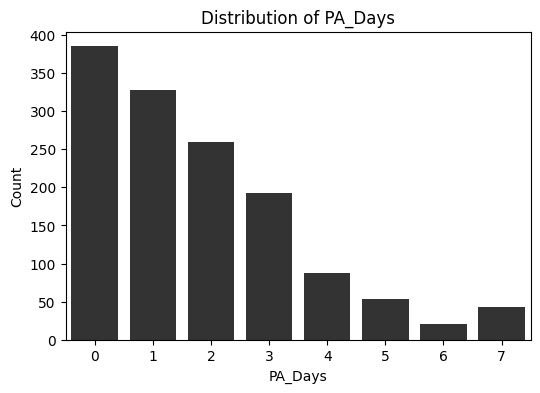

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x="PA_Days", data=data, color="#333333")
plt.title("Distribution of PA_Days")
plt.xlabel("PA_Days")
plt.ylabel("Count")

# the distribution of PA_Days is right-skewed, with a large number of observations
# having 0 PA_Days and a small number of observations having 7 PA_Days.
# This suggests that most individuals in the dataset do not engage in physical
# activity on a regular basis, while a smaller proportion of individuals engage
# in physical activity every day.

plt.savefig("paper/figures/pa_days_distribution.png")


(b) Compute the five-number summary as well as the mean and standard deviation for PA_Days.
What does this data say about the physical activity of participants?

In [11]:
# compute the five-number summary as well as the mean and std-dev for PA_Days
pa_days_summary = data["PA_Days"].describe()
print(pa_days_summary)

# the median PA_Days is 1. This means that at least 50% of the individuals in
# the dataset engage in physical activity for 1 day or less per week.

# and the upper quartile is 3.0 which means that 25% of the individuals in the
# dataset engage in physical activity for 3 days or more per week.

count    1369.000000
mean        1.798393
std         1.758097
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max         7.000000
Name: PA_Days, dtype: float64


## Question 4
Transform the variable `BMI` into a categorical variable `BMI_Class` by classifying each `BMI` value $x$ according to the following Asian BMI cut-off points.

In [12]:
# transform BMI into a categorical variable BMI_Class by classifying
# each BMI value x according to the following Asian BMI cut-off points:

bmi_classes = ["Underweight", "Normal", "Overweight", "Obese"]

def create_bmi_class(bmi):
    if bmi < 18.5: return "Underweight"
    elif bmi < 23: return "Normal"
    elif bmi < 27.5: return "Overweight"
    else: return "Obese"

data['BMI_Class'] = data['BMI'].dropna().apply(create_bmi_class)

Compare the proportions of each `BMI_Class` across countries.

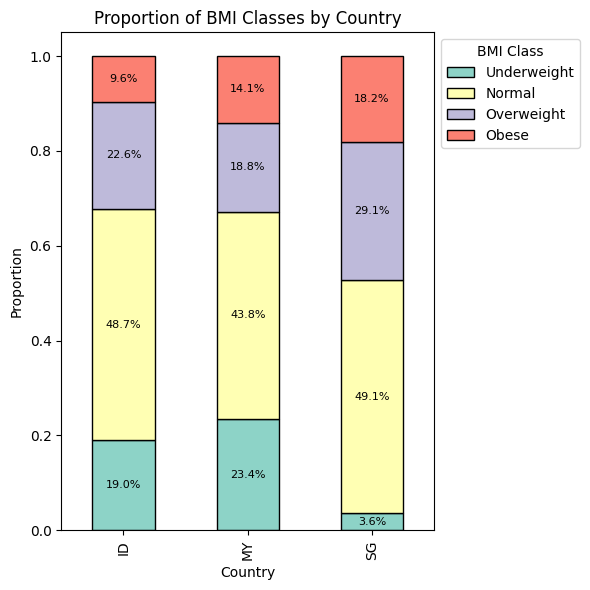

In [13]:
# Compare the proportions of each BMI_Class across countries

# use a stacked percentage bar chart
bmi_country_counts = data.groupby(['Country', 'BMI_Class']).size().unstack(fill_value=0)
bmi_country_props = bmi_country_counts.div(bmi_country_counts.sum(axis=1), axis=0)

# order the BMI classes
bmi_country_props = bmi_country_props[bmi_classes]

bmi_country_props.plot(kind='bar', stacked=True, figsize=(6, 6), color=sns.color_palette("Set3", n_colors=len(bmi_classes)), edgecolor='black')
plt.title("Proportion of BMI Classes by Country")
plt.xlabel("Country")
plt.ylabel("Proportion")

# add the percentage labels on the bars
for i, country in enumerate(bmi_country_props.index):
    cumulative = 0
    for bmi_class in bmi_classes:
        proportion = bmi_country_props.loc[country, bmi_class]
        if proportion > 0:
            plt.text(i, cumulative + proportion / 2, f"{proportion:.1%}", ha='center', va='center', fontsize=8)
            cumulative += proportion

plt.legend(title="BMI Class", bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.savefig("paper/figures/bmi_class_by_country.png")


Regular physical activity can help maintain a healthy body weight by getting rid of excess body fat. As we exercise, our body burns calories, thus burning off our body fat.

## Question 5
With an appropriate visualisation, analyse the relationship between time spent daily on physical activity and BMI. Choose an appropriate way, using variable(s) in the data set, to quantify time spent daily on physical activity. Justify your choice.

In [36]:
import pandas as pd

def encode_MET(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # Calculate MET values
    df["MET_Weekly_Hours"] = (
        df['MIA_Daily_Hours'] * df['MIA_Weekly_Days'] * 4 +
        df['VA_Daily_Hours'] * df['VA_Weekly_Days'] * 8
    )
    df["MET_Weekly_Minutes"] = df["MET_Weekly_Hours"] * 60
    df["MET_Daily_Hours"] = df["MET_Weekly_Hours"] / 7

    # Initialize column
    df["PA_Level"] = "Insufficiently Active"

    # Conditions
    hepa_active = (
        (df["VA_Weekly_Days"] >= 3) & (df["MET_Weekly_Minutes"] >= 1500)
    ) | (
        (df["VA_Weekly_Days"] + df["MIA_Weekly_Days"] + df["PA_Days"] >= 7) &
        (df["MET_Weekly_Minutes"] >= 3000)
    )

    minimal_active = (
        (df["VA_Weekly_Days"] >= 3) & (df["VA_Daily_Hours"] >= 0.333)
    ) | (
        (df["MIA_Weekly_Days"] >= 5) & (df["MIA_Daily_Hours"] >= 0.5)
    ) | (
        (df["MET_Weekly_Minutes"] >= 600)
    )

    # Apply categories (order matters)
    df.loc[minimal_active, "PA_Level"] = "Minimally Active"
    df.loc[hepa_active, "PA_Level"] = "HEPA Active"

    return df

In [37]:
data = encode_MET(data)

Correlation between MET_Daily_Hours and BMI: 0.1465
Regression line: BMI = 0.1017 * MET_Daily_Hours + 21.4525


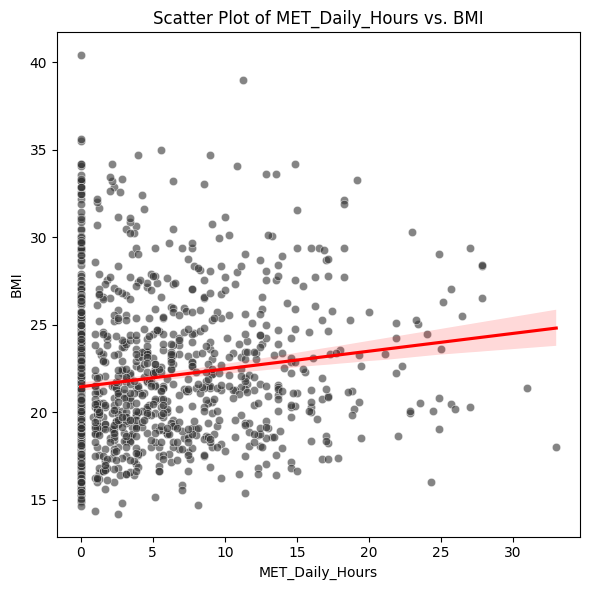

In [38]:
# generate the visualisation: scatter plot with MET_Daily_Hours on x-axis and BMI on y-axis, colored by BMI_Class
plt.figure(figsize=(6, 6))
sns.scatterplot(data=data, x='MET_Daily_Hours', y='BMI', color='#333333', alpha=0.6)

# print out the correlation coefficient between MET_Daily_Hours and BMI
correlation = data[['MET_Daily_Hours', 'BMI']].corr().iloc[0, 1]
print(f"Correlation between MET_Daily_Hours and BMI: {correlation:.4f}")

# print equation of regression line: y = mx + b
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(data['MET_Daily_Hours'], data['BMI'])
print(f"Regression line: BMI = {slope:.4f} * MET_Daily_Hours + {intercept:.4f}")

sns.regplot(data=data, x='MET_Daily_Hours', y='BMI', scatter=False, color='red', )

plt.title("Scatter Plot of MET_Daily_Hours vs. BMI")

plt.xlabel("MET_Daily_Hours")
plt.ylabel("BMI")

plt.tight_layout()
plt.savefig("paper/figures/met_daily_hours_bmi_scatter.png")



(b) Do the same as what was done for part (a), but for each of the respective countries. Is there any difference when comparing between countries; as well as comparing with the findings for part (a)? Give a brief description of your observation.

Correlation between MET_Daily_Hours and BMI for SG: 0.1374
Regression line for SG: BMI = 0.0820 * MET_Daily_Hours + 22.6901
Correlation between MET_Daily_Hours and BMI for MY: 0.0423
Regression line for MY: BMI = 0.0299 * MET_Daily_Hours + 21.9379
Correlation between MET_Daily_Hours and BMI for ID: 0.1503
Regression line for ID: BMI = 0.1056 * MET_Daily_Hours + 21.3874


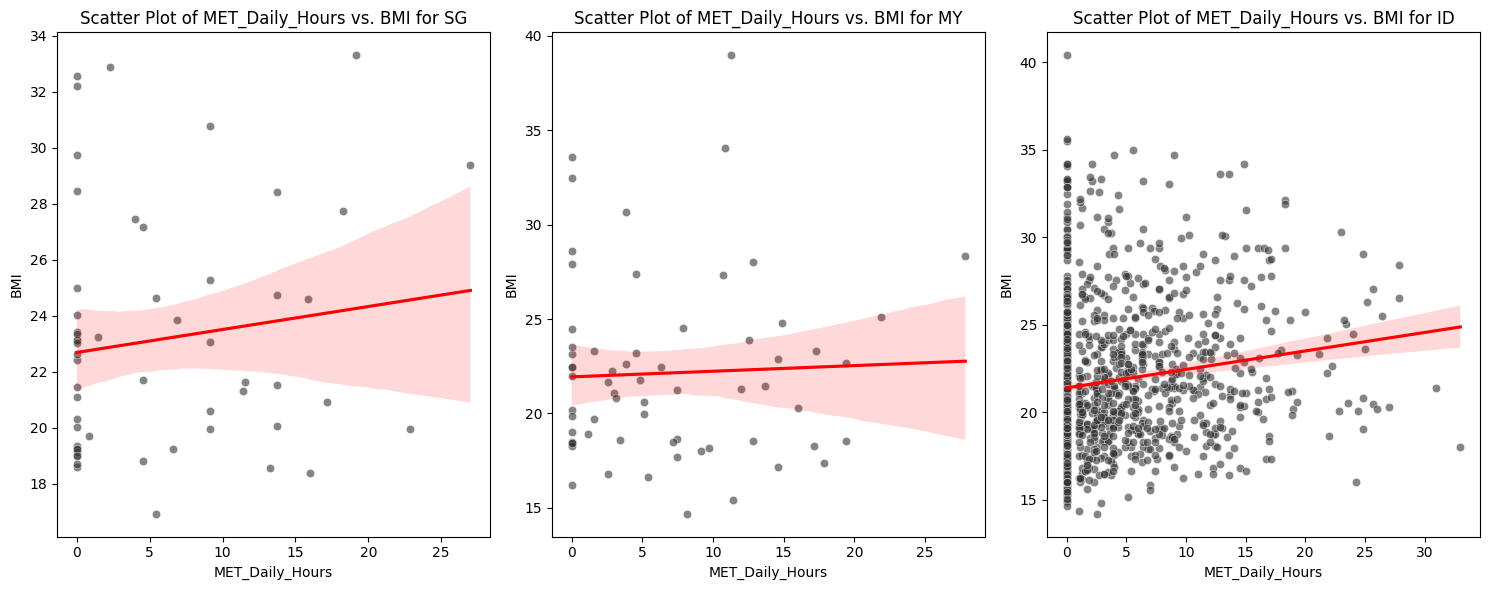

In [39]:
# for each country:

# generate the visualisation: scatter plot with MET_Daily_Hours on x-axis and BMI on y-axis, colored by BMI_Class
# print out the correlation coefficient between MET_Daily_Hours and BMI
# print equation of regression line: y = mx + b

plt.figure(figsize=(15, 6))

for country in data['Country'].unique():
    country_data = data[data['Country'] == country]

    plt.subplot(1, 3, list(data['Country'].unique()).index(country) + 1)
    sns.scatterplot(data=country_data, x='MET_Daily_Hours', y='BMI', color='#333333', alpha=0.6)

    correlation = country_data[['MET_Daily_Hours', 'BMI']].corr().iloc[0, 1]
    print(f"Correlation between MET_Daily_Hours and BMI for {country}: {correlation:.4f}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(country_data['MET_Daily_Hours'], country_data['BMI'])
    print(f"Regression line for {country}: BMI = {slope:.4f} * MET_Daily_Hours + {intercept:.4f}")

    sns.regplot(data=country_data, x='MET_Daily_Hours', y='BMI', scatter=False, color='red')

    plt.title(f"Scatter Plot of MET_Daily_Hours vs. BMI for {country}")
    plt.xlabel("MET_Daily_Hours")
    plt.ylabel("BMI")

plt.tight_layout()
plt.savefig(f"paper/figures/met_daily_hours_bmi_scatter_all.png")

# strength of relationship across all countries is weak, with correlation coefficients:
# SG: 0.22
# MY: -0.03
# ID: 0.14

# slope of regression line:
# SG: 0.84
# MY: -0.13
# ID: 0.53

# the relationship between PA and BMI found in part (a) is weakly positive, with a
# correlation coefficient of 0.13.
# # This suggests that there is a slight tendency for individuals who engage in
# more physical activity to have higher BMI values, but the relationship is not strong.

# only malaysia has a negative slope, which suggests that higher PA hours are associated with lower BMI in Malaysia
# so it could be inconclusive to say that there is a consistent relationship between
# PA and BMI across all three countries, as the strength and direction of the relationship varies.

# this could be explained by the fact the BMI is not a perfect measure of health or fitness,
# as it is calculated based on weight and height alone and does not account for
# factors such as muscle mass, body composition, and overall lifestyle.

# Therefore, it is possible for individuals with high levels of physical activity
# to have higher BMI values if they have more muscle mass or a different body composition.
# Additionally, other factors such as diet, genetics, and socioeconomic status
# could also influence the relationship between PA and BMI in different countries.

## Question 6
Your friend Dean claims that while a higher level of physical activity is positively associated to relaxedness, gender is a confounder in the relationship between the two variables. Investigate Dean’s claim within the data set with the help of the following:
- Choose a variable in the data set that you think best represents levels of physical activity, justifying your choice. Recode your chosen variable, using a reasonable classification, such that it is a binary categorical variable with values “High PA” and “Low PA”.
- Recode the variable Relaxedness, using a reasonable classification, such that it is a binary categorical variable with values “Relaxed” and “Not Relaxed”.

In [18]:
# table of pa_level
pa_level_counts = data['PA_Level'].value_counts()
print(pa_level_counts)

PA_Level
Insufficiently Active    669
Minimally Active         450
HEPA Active              250
Name: count, dtype: int64


In [19]:
def encode_PA_level(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # Encode PA_Days into a binary variable
    df["PA_Level"] = df["PA_Level"].apply(lambda x: "High PA" if x == "HEPA Active" else "Low PA")
    return df

data = encode_PA_level(data)

In [20]:
# Relaxation vs. physical activity

# relaxedness: Over the last two weeks, I have been feeling relaxed.
# None of the time (1)
# Rarely (2)
# Sometimes (3)
# Often (4)
# All the time (5)

def recode_relaxedness(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # Recode Relaxedness into a binary variable
    df["Relaxed_Level"] = df["Relaxedness"].apply(lambda x: "Relaxed" if x >= 4 else "Not Relaxed")

    return df

data = recode_relaxedness(data)

In [21]:
# create a contingency table of PA_Level and Relaxed_Level
contingency_table = pd.crosstab(data["PA_Level"], data["Relaxed_Level"])
print(contingency_table)

# proportion of "Relaxed" in "High PA" group
prop_relaxed_high_pa = contingency_table.loc["High PA", "Relaxed"] / contingency_table.loc["High PA"].sum()

# proportion of "Relaxed" in "Low PA" group
prop_relaxed_low_pa = contingency_table.loc["Low PA", "Relaxed"] / contingency_table.loc["Low PA"].sum()

print(f"Proportion of 'Relaxed' in 'High PA' group: {prop_relaxed_high_pa:.4f}")
print(f"Proportion of 'Relaxed' in 'Low PA' group: {prop_relaxed_low_pa:.4f}")

# overall there is a positive association between physical activity and relaxedness,
# as a higher proportion of individuals with "High PA" are classified as "Relaxed"
# compared to those with "Low PA". However, the relationship is not very strong,
# and there are still a significant number of individuals in both PA levels who
# are classified as "Not Relaxed".

# It is worth noting that the study referenced in the article suggesting that
# physical activity can reduce cortisol levels and promote relaxation may not be
# directly applicable to the population in this dataset, as the participants
# predominantly had breast cancer, included few males and no older adults.

# In addition, the variable selected PA_Days may not fully capture the complexity
# of physical activity and its relationship with relaxation, as it does not account
# for factors such as the type, intensity, and duration of physical activity,
# which could also influence relaxation levels.

# We opted for PA_Days as the variable to represent physical activity levels
# instead of MIA_Weekly_Days because PA_Days captures the overall frequency of
# physical activity, which seems to be more relevant.

Relaxed_Level  Not Relaxed  Relaxed
PA_Level                           
High PA                123      127
Low PA                 527      592
Proportion of 'Relaxed' in 'High PA' group: 0.5080
Proportion of 'Relaxed' in 'Low PA' group: 0.5290


In [22]:
# investigate whether gender is a confounding variable in the relationship between PA and relaxedness

for gender in data['Gender'].unique():
    gender_data = data[data['Gender'] == gender]
    table = pd.crosstab(gender_data["PA_Level"], gender_data["Relaxed_Level"])
    print(f"Contingency table for {gender}:")
    print(table)

    # proportion of "Relaxed" in "High PA" group
    prop_relaxed_high_pa = table.loc["High PA", "Relaxed"] / table.loc["High PA"].sum()
    prop_relaxed_low_pa = table.loc["Low PA", "Relaxed"] / table.loc["Low PA"].sum()

    print(f"Proportion of 'Relaxed' in 'High PA' group for {gender}: {prop_relaxed_high_pa:.4f}")
    print(f"Proportion of 'Relaxed' in 'Low PA' group for {gender}: {prop_relaxed_low_pa:.4f}")
    print()

# the relationship between PA and relaxedness is consistent across genders, with
# a weak positive association for both males and females.

Contingency table for M:
Relaxed_Level  Not Relaxed  Relaxed
PA_Level                           
High PA                 64       44
Low PA                 377      405
Proportion of 'Relaxed' in 'High PA' group for M: 0.4074
Proportion of 'Relaxed' in 'Low PA' group for M: 0.5179

Contingency table for F:
Relaxed_Level  Not Relaxed  Relaxed
PA_Level                           
High PA                 59       83
Low PA                 150      187
Proportion of 'Relaxed' in 'High PA' group for F: 0.5845
Proportion of 'Relaxed' in 'Low PA' group for F: 0.5549



Besides regular physical activity, good diet and nutrition is important in keeping our bodies healthy. Eating enough fruits and vegetables every day is one way we can try to achieve a healthier diet.

## Question 7
According to the Health Promotion Board, it is recommended to eat 2 servings of fruit and 2 servings of vegetables per day. Your same friend Dean suspects that more than half of all Singaporean university students consume less than the recommended servings of fruits per day. Using the variable `Fruits`, conduct a suitable test to test Dean’s hypothesis. Comment on whether the result validates Dean’s suspicion, considering the limitations or assumptions of the sample.

In [23]:
singapore_data = data[data['Country'] == 'SG']
less_than_2_servings = (singapore_data['Fruits'] < 2).sum()
total_singapore_students = len(singapore_data)

# We test whether more than half of all singaporean university students consume
# less than 2 servings of fruits per day at the 5% significance level.

# H_0 : p = 0.5
# H_1 : p > 0.5

from scipy import stats

test = stats.binomtest(less_than_2_servings, total_singapore_students, p=0.5, alternative='greater')
print(f"Observed proportion: {less_than_2_servings / total_singapore_students:.4f}")
print(f"p-value: {test.pvalue:.4f}")

# The p-value of the one-sided test is 0.6742 > 0.05, so we fail to reject the 
# null hypothesis. There is not enough evidence to conclude that more than half
# of all singaporean university students consume less than 2 servings of fruits
# per day at the 5% significance level.

# Comment: the result does not validate Dean's suspicion. However, it is important
# to note that the sample of SG students is not representative of the population
# because it only consists of NIE students, introducing potential sampling bias.
# Therefore, the results of this test may not be generalizable to all Singaporean
# university students.

print(f"Sample size of Singaporean students: {total_singapore_students}")
print(f"Number of Singaporean students consuming less than 2 servings of fruits per day: {less_than_2_servings}")
# In addition there are only 44 Singaporean students in the dataset, which is a
# relatively small sample size. This could lead to low statistical power, making
# it difficult to detect a true effect even if one exists.

# For instance, the threshold for the observed proportion to be statistically
# significant at the 5% level would be 27 out of 44 students consuming less than
# 2 servings of fruits per day, which corresponds to a proportion of 0.6136.
threshold = stats.binom.ppf(0.95, n=total_singapore_students, p=0.5)
print(f"Threshold for observed proportion to be significant at 5% level: {threshold:.4f}")


Observed proportion: 0.4909
p-value: 0.6061
Sample size of Singaporean students: 55
Number of Singaporean students consuming less than 2 servings of fruits per day: 27
Threshold for observed proportion to be significant at 5% level: 34.0000


# Section 3
At this stage, you would have explored a few variables and made use of data to ask and answer questions. Let’s dive deeper for a second round of data analysis!

## Question 8
Perform an additional data analysis that builds on what you have done so far. You may choose to explore new variables, ideas or perspectives, so long as you do not repeat exactly what you have done for any of the previous questions.

In [24]:
# Investigate if eating more fruits is associated with better sleep

# Create a indicator variable for low sleep and high sleep based on Hours_Slept
data["Sleep_Quality"] = data["Hours_Slept"].apply(lambda x: "High Sleep" if x >= 8 else "Low Sleep")

bins = [0, 6, 8, float("inf")]
labels = [0, 1, 2]
data["Sleep_Group"] = pd.cut(data["Hours_Slept"], bins=bins, labels=labels, right=True)

# Create a contingency table of Sleep_Quality and Fruits (categorized as <2 servings vs >=2 servings)
data["Fruit_Consumption"] = data["Fruits"].apply(lambda x: "<2 servings" if x < 2 else ">=2 servings")
contingency_table = pd.crosstab(data["Sleep_Quality"], data["Fruit_Consumption"])
print(contingency_table)

# proportion of "High Sleep" in "<2 servings" group
prop_high_sleep_low_fruit = contingency_table.loc["High Sleep", "<2 servings"] / contingency_table.loc[:, "<2 servings"].sum()
# proportion of "High Sleep" in ">=2 servings" group
prop_high_sleep_high_fruit = contingency_table.loc["High Sleep", ">=2 servings"] / contingency_table.loc[:, ">=2 servings"].sum()

print(f"Proportion of 'High Sleep' in '<2 servings' group: {prop_high_sleep_low_fruit:.4f}")
print(f"Proportion of 'High Sleep' in '>=2 servings' group: {prop_high_sleep_high_fruit:.4f}")

# the proportion of individuals with "High Sleep" is higher in the ">=2 servings"
# group (0.6110) compared to the "<2 servings" group (0.5800), suggesting a
# positive association between fruit consumption and sleep quality. However,
# this relationship is not very strong, and there are still a significant number
# of individuals in both groups who have "Low Sleep". This could be explained by
# the fact that sleep quality is influenced by many factors beyond just fruit
# consumption, such as stress levels, physical activity, and overall lifestyle
# habits.

Fruit_Consumption  <2 servings  >=2 servings
Sleep_Quality                               
High Sleep                 240           302
Low Sleep                  398           429
Proportion of 'High Sleep' in '<2 servings' group: 0.3762
Proportion of 'High Sleep' in '>=2 servings' group: 0.4131


In [25]:
# Investigate if the observed relationship between fruit consumption and sleep
# quality is statistically significant at the 5% level using a chi-squared test
# of independence.

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

# The p-value of the chi-squared test is 0.1841 > 0.05, so we fail to reject the
# null hypothesis. There is not enough evidence to conclude that there is a
# statistically significant association between fruit consumption and sleep quality
# at the 5% significance level. This suggests that the observed relationship between
# fruit consumption and sleep quality may be due to random chance rather than a
# true underlying association.

Chi-squared statistic: 1.7941
p-value: 0.1804


In [26]:
# Investigate if relaxedness is associated with better sleep

contingency_table = pd.crosstab(data["Sleep_Quality"], data["Relaxed_Level"])
print(contingency_table)

# proportion of "High Sleep" in "Relaxed" group
prop_high_sleep_relaxed = contingency_table.loc["High Sleep", "Relaxed"] / contingency_table.loc[:, "Relaxed"].sum()
# proportion of "High Sleep" in "Not Relaxed" group
prop_high_sleep_not_relaxed = contingency_table.loc["High Sleep", "Not Relaxed"] / contingency_table.loc[:, "Not Relaxed"].sum()

print(f"Proportion of 'High Sleep' in 'Relaxed' group: {prop_high_sleep_relaxed:.4f}")
print(f"Proportion of 'High Sleep' in 'Not Relaxed' group: {prop_high_sleep_not_relaxed:.4f}")

Relaxed_Level  Not Relaxed  Relaxed
Sleep_Quality                      
High Sleep             248      294
Low Sleep              402      425
Proportion of 'High Sleep' in 'Relaxed' group: 0.4089
Proportion of 'High Sleep' in 'Not Relaxed' group: 0.3815


In [27]:
# Investigate if the observed relationship between relaxation and sleep
# quality is statistically significant at the 5% level using a chi-squared test
# of independence.

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

# The p-value of the chi-squared test is 0.4142 > 0.05, so we fail to reject the
# null hypothesis. There is not enough evidence to conclude that there is a
# statistically significant association between relaxation and sleep quality
# at the 5% significance level. This suggests that the observed relationship between
# relaxation and sleep quality may be due to random chance rather than a
# true underlying association.

Chi-squared statistic: 0.9574
p-value: 0.3279


In [28]:
# Investigate if BMI is associated with sleep quality

contingency_table = pd.crosstab(data["Sleep_Quality"], data["BMI_Class"])
print(contingency_table)

# proportion of "High Sleep" in each BMI class
for bmi_class in data["BMI_Class"].unique():
    prop_high_sleep = contingency_table.loc["High Sleep", bmi_class] / contingency_table.loc[:, bmi_class].sum()
    print(f"Proportion of 'High Sleep' in '{bmi_class}' group: {prop_high_sleep:.4f}")

BMI_Class      Normal  Obese  Overweight  Underweight
Sleep_Quality                                        
High Sleep        283     44         116           99
Low Sleep         381     95         195          156
Proportion of 'High Sleep' in 'Obese' group: 0.3165
Proportion of 'High Sleep' in 'Overweight' group: 0.3730
Proportion of 'High Sleep' in 'Normal' group: 0.4262
Proportion of 'High Sleep' in 'Underweight' group: 0.3882


In [29]:
# Investigate if the observed relationship between BMI and sleep
# quality is statistically significant at the 5% level using a chi-squared test
# of independence.

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

# The p-value of the chi-squared test is 0.0496 < 0.05, so we reject the
# null hypothesis. There is enough evidence to conclude that there is a
# statistically significant association between BMI and sleep quality
# at the 5% significance level. This suggests that BMI may be an important factor
# influencing sleep quality, and further investigation into the nature of this
# relationship could be warranted.

Chi-squared statistic: 6.9546
p-value: 0.0734


## Question 9
Suppose that you were able to reconduct this survey. If you were able to collect one more variable (beyond this data set) that could be useful in studying health behaviour amongst university students, what would it be, and why? Explain how you would measure that variable, and any considerations you may have when interpreting information from that variable.

In [30]:
# OPTION A: Sleep quality among university students

# Sleep quality among university students. This is a relevant variable to
# in studying health behaviour because sleep quality is an important aspect of
# overall health and well-being, and it can be influenced by various lifestyle
# factors such as physical activity, diet, stress levels, and BMI.

# Understanding the relationship between these factors and sleep quality can provide
# insights into how to promote better sleep habits and improve overall health
# outcomes among university students.

# Currently, only contains the variable Hours_Slept, which is a discrete variable
# representing the number of hours slept per night. We can create a new variable
# Sleep_Quality by categorizing Hours_Slept into "High Sleep" (8 or more hours) and "Low Sleep" (less than 8 hours).
# However, it is important to note that sleep quality is a complex construct that
# can be influenced by many factors beyond just the number of hours slept,
# such as sleep disturbances, sleep latency, and overall sleep patterns.
# Therefore, while categorizing sleep quality based on hours slept and using it as a proxy
# can provide some insights, it may not fully capture the nuances of sleep quality
# among university students.

# Therefore, it is important to interpret the results with caution and consider
# the limitations of using hours slept as a proxy for sleep quality.

# OPTION B: Relaxation among university students

# Currently, the data set contains the variable Relaxedness, which is a numerical
# nominal variable representing the self-reported level of relaxation over the
# last two weeks on a scale from 1 to 5. If I could reconduct the survey,
# I would consider collecting another variable that captures the frequency of
# relaxation practices, such as mindfulness meditation, yoga, or leisure activities.
# This variable could be measured on a similar scale to Relaxedness, indicating
# how often individuals engage in relaxation practices (e.g., Never, Rarely,
# Sometimes, Often, Always).

# This additional variable would provide more context to the Relaxedness variable
# and allow for a more comprehensive analysis of the relationship between relaxation
# and other health behaviors, such as physical activity and sleep quality. It would
# also help to identify potential interventions or strategies to promote relaxation
# among university students, which could ultimately improve their overall well-being.


## Question 10
Evaluate 2 aspects of the data analysis that you have done in Part B. You may choose to discuss the strengths (how your analysis value-adds to understanding the topic of interest) and/or the limitations (how your analysis affects the generalisability of the findings).

In [31]:
# Strengths



# Weaknesses